# TEST

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import importlib.util

In [46]:
# ============================================================
# Cargar pipeline.py
# ============================================================
from pipeline import *

In [80]:
# ============================================================
# Parámetros OFDM según Modulator.yaml
# ============================================================

FFT_SIZE = 1024
CP_LEN = 256
NUM_SYMBOLS = 100

FS_BB = 50_000_000.0                  # Hz, sample_rate del YAML
DELTA_F = FS_BB / FFT_SIZE            # 48_828.125 Hz

T_U = 1.0 / DELTA_F                   # duración útil OFDM = 20.48 us
T_SYM = (FFT_SIZE + CP_LEN) / FS_BB   # duración total con CP = 25.6 us

FS_SLOW = 1.0 / T_SYM                 # 39_062.5 Hz si usas todos los símbolos

# Si aplicas sensing_symbol_stride = 20:
SENSING_SYMBOL_STRIDE = 20
FS_SLOW_SENSING = FS_SLOW / SENSING_SYMBOL_STRIDE  # 1953.125 Hz

CENTER_FREQ = 3_500_000_000.0         # Hz

RANGE_FFT_SIZE = 1024
DOPPLER_FFT_SIZE = 100

SYNC_SYMBOL_INDEX = 1
ZC_ROOT = 25

PILOT_SUBCARRIERS = np.array([
    571, 631, 692, 752, 812, 872, 933, 993,
    29, 89, 150, 210, 270, 330, 391, 451
], dtype=int)

# Para iq_rx.bin si viene crudo de USRP según wire_format_rx: sc16
USRP_FILE_DTYPE = "complex64" # "sc16_interleaved"  # cada muestra es un complejo de 32 bits (16 bits I + 16 bits Q)

In [81]:
# ============================================================
# Elegir tamaño STFT de forma robusta según longitud disponible
# ============================================================
n_slow_total = 100

# Resolución Doppler objetivo [Hz]
DF_TARGET = 5.0

nperseg = int(2 ** np.ceil(np.log2(FS_SLOW / DF_TARGET)))

# No permitir que la ventana ocupe más de la mitad de la señal
nperseg = min(nperseg, 2 ** int(np.floor(np.log2(n_slow_total // 2))))

# Límites prácticos
nperseg = int(np.clip(nperseg, 64, 8192))

noverlap = int(0.99 * nperseg)
nfft = 2 * nperseg

print(f"n_slow_total={n_slow_total}")
print(f"nperseg={nperseg}, noverlap={noverlap}, nfft={nfft}")
print(f"Resolución Doppler aprox = {FS_SLOW / nperseg:.2f} Hz")
print(f"Espaciado de bins = {FS_SLOW / nfft:.2f} Hz")

n_slow_total=100
nperseg=64, noverlap=63, nfft=128
Resolución Doppler aprox = 610.35 Hz
Espaciado de bins = 305.18 Hz


## Vacío

In [82]:
# ============================================================
# Adaptar IQ -> rejillas OFDM completas X[k,m], Y[k,m]
# ============================================================
TX_FILE = "vacio/iq_tx.bin"
RX_FILE = "vacio/iq_rx.bin"

obs = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE,
    rx_file_path=RX_FILE,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

print("x_grid shape:", obs.x_grid.shape)
print("y_grid shape:", obs.y_grid.shape)

x_grid shape: (100, 1024)
y_grid shape: (100, 1024)


In [83]:
# ============================================================
# Pipeline OpenISAC-like completo:
# Y/X -> clutter suppression -> IFFT en subportadoras
# -> selección de bin de retardo -> STFT
# ============================================================
(spec_db, f_axis, t_axis), inter = microdoppler_spectrogram_from_full_grid(
    y_grid=obs.y_grid,
    x_grid=obs.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

KeyError: 'selected_delay_bin'

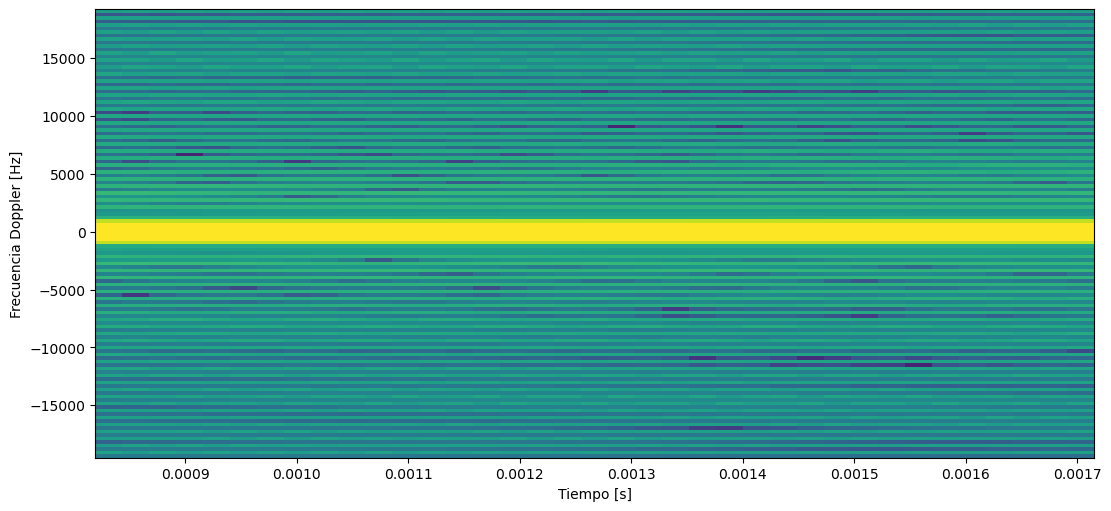

In [115]:
# ============================================================
# Visualización
# ============================================================
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
extent = [t_axis[0], t_axis[-1], f_axis[0], f_axis[-1]]

vmin = -90 # min(spec_db_1.min(), spec_db_2.min())
vmax = 10 # max(spec_db_1.max(), spec_db_2.max())

im = ax.imshow(
    spec_db,
    aspect="auto",
    origin="lower",
    extent=extent,
    vmin=vmin,
    vmax=vmax,
)

ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Frecuencia Doppler [Hz]")
ax.set_title(
    f"Espectrograma micro-Doppler (OpenISAC-like) | "
    f"delay bin = {inter['selected_delay_bin']}"
)
fig.colorbar(im, ax=ax, label="Potencia [dB]")
plt.show()

print("Delay bin seleccionado:", inter["selected_delay_bin"])

## Vaso de carton caliente

In [ ]:
# ============================================================
# Adaptar IQ -> rejillas OFDM completas X[k,m], Y[k,m]
# ============================================================
TX_FILE_1 = "carton/caliente/iq_tx_1.bin"
RX_FILE_1 = "carton/caliente/iq_rx_1.bin"
TX_FILE_2 = "carton/caliente/iq_tx_2.bin"
RX_FILE_2 = "carton/caliente/iq_rx_2.bin"

obs_1 = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE_1,
    rx_file_path=RX_FILE_1,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

obs_2 = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE_2,
    rx_file_path=RX_FILE_2,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

In [ ]:
# ============================================================
# Pipeline OpenISAC-like completo:
# Y/X -> clutter suppression -> IFFT en subportadoras
# -> selección de bin de retardo -> STFT
# ============================================================
(spec_db_1, f_axis_1, t_axis_1), inter_1 = microdoppler_spectrogram_from_full_grid(
    y_grid=obs_1.y_grid,
    x_grid=obs_1.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

(spec_db_2, f_axis_2, t_axis_2), inter_2 = microdoppler_spectrogram_from_full_grid(
    y_grid=obs_2.y_grid,
    x_grid=obs_2.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

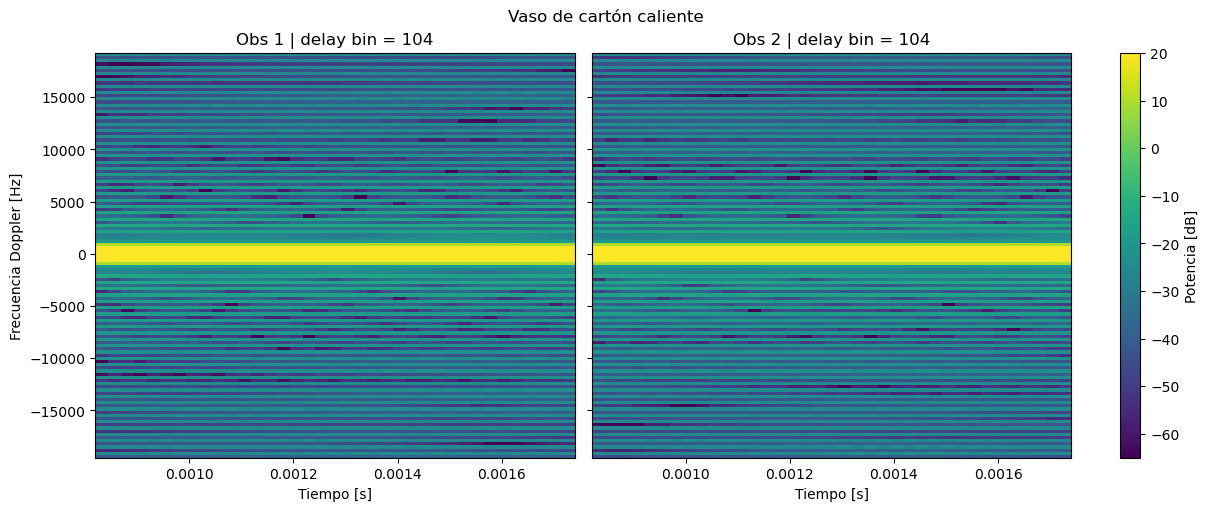

Delay bins seleccionados: 104 104


In [ ]:
# ============================================================
# Visualización
# ============================================================
selected_delay_bin_1 = (
    int(inter_1.get("selected_delay_bin")) if isinstance(inter_1, dict) and "selected_delay_bin" in inter_1 else None
)
selected_delay_bin_2 = (
    int(inter_2.get("selected_delay_bin")) if isinstance(inter_2, dict) and "selected_delay_bin" in inter_2 else None
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)
fig.suptitle("Vaso de cartón caliente")

extent1 = (t_axis_1[0], t_axis_1[-1], f_axis_1[0], f_axis_1[-1])
extent2 = (t_axis_2[0], t_axis_2[-1], f_axis_2[0], f_axis_2[-1])

vmin = -90 # min(spec_db_1.min(), spec_db_2.min())
vmax = 10 # max(spec_db_1.max(), spec_db_2.max())

im0 = axs[0].imshow(
    spec_db_1,
    aspect="auto",
    origin="lower",
    extent=extent1,
    vmin=vmin,
    vmax=vmax,
)
axs[0].set_xlabel("Tiempo [s]")
axs[0].set_ylabel("Frecuencia Doppler [Hz]")
axs[0].set_title(f"Obs 1 | delay bin = {selected_delay_bin_1}")

im1 = axs[1].imshow(
    spec_db_2,
    aspect="auto",
    origin="lower",
    extent=extent2,
    vmin=vmin,
    vmax=vmax,
)
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_title(f"Obs 2 | delay bin = {selected_delay_bin_2}")

fig.colorbar(im0, ax=axs, label="Potencia [dB]")

plt.show()

print("Delay bins seleccionados:", selected_delay_bin_1, selected_delay_bin_2)

## Vaso de carton templado

In [ ]:
# ============================================================
# Adaptar IQ -> rejillas OFDM completas X[k,m], Y[k,m]
# ============================================================
TX_FILE_1 = "carton/templado/iq_tx_1.bin"
RX_FILE_1 = "carton/templado/iq_rx_1.bin"
TX_FILE_2 = "carton/templado/iq_tx_2.bin"
RX_FILE_2 = "carton/templado/iq_rx_2.bin"

obs_1 = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE_1,
    rx_file_path=RX_FILE_1,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

obs_2 = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE_2,
    rx_file_path=RX_FILE_2,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

In [ ]:
# ============================================================
# Pipeline OpenISAC-like completo:
# Y/X -> clutter suppression -> IFFT en subportadoras
# -> selección de bin de retardo -> STFT
# ============================================================
(spec_db_1, f_axis_1, t_axis_1), inter_1 = microdoppler_spectrogram_from_full_grid(
    y_grid=obs_1.y_grid,
    x_grid=obs_1.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

(spec_db_2, f_axis_2, t_axis_2), inter_2 = microdoppler_spectrogram_from_full_grid(
    y_grid=obs_2.y_grid,
    x_grid=obs_2.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

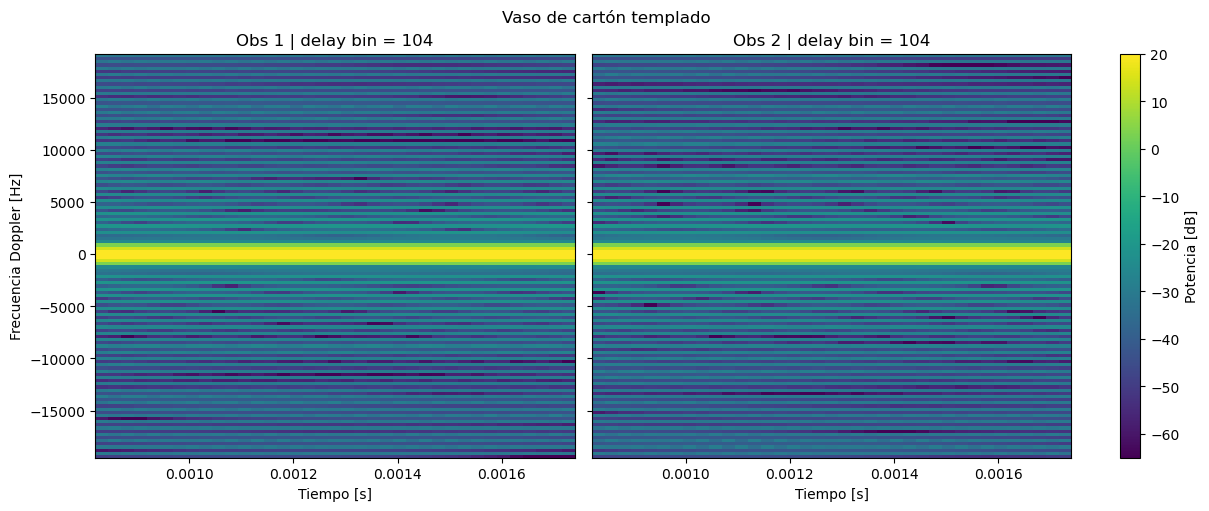

Delay bins seleccionados: 104 104


In [ ]:
# ============================================================
# Visualización
# ============================================================
selected_delay_bin_1 = (
    int(inter_1["selected_delay_bin"])
    if isinstance(inter_1, dict) and "selected_delay_bin" in inter_1 and inter_1["selected_delay_bin"] is not None
    else None
)
selected_delay_bin_2 = (
    int(inter_2["selected_delay_bin"])
    if isinstance(inter_2, dict) and "selected_delay_bin" in inter_2 and inter_2["selected_delay_bin"] is not None
    else None
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)
fig.suptitle("Vaso de cartón templado")

extent1 = (t_axis_1[0], t_axis_1[-1], f_axis_1[0], f_axis_1[-1])
extent2 = (t_axis_2[0], t_axis_2[-1], f_axis_2[0], f_axis_2[-1])

vmin = -90 # min(spec_db_1.min(), spec_db_2.min())
vmax = 10 # max(spec_db_1.max(), spec_db_2.max())

im0 = axs[0].imshow(
    spec_db_1,
    aspect="auto",
    origin="lower",
    extent=extent1,
    vmin=vmin,
    vmax=vmax,
)
axs[0].set_xlabel("Tiempo [s]")
axs[0].set_ylabel("Frecuencia Doppler [Hz]")
axs[0].set_title(f"Obs 1 | delay bin = {selected_delay_bin_1}")

im1 = axs[1].imshow(
    spec_db_2,
    aspect="auto",
    origin="lower",
    extent=extent2,
    vmin=vmin,
    vmax=vmax,
)
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_title(f"Obs 2 | delay bin = {selected_delay_bin_2}")

fig.colorbar(im0, ax=axs, label="Potencia [dB]")

plt.show()

print("Delay bins seleccionados:", selected_delay_bin_1, selected_delay_bin_2)

## Vaso de carton frío

In [ ]:
# ============================================================
# Adaptar IQ -> rejillas OFDM completas X[k,m], Y[k,m]
# ============================================================
TX_FILE_1 = "carton/frio/iq_tx_1.bin"
RX_FILE_1 = "carton/frio/iq_rx_1.bin"
TX_FILE_2 = "carton/frio/iq_tx_2.bin"
RX_FILE_2 = "carton/frio/iq_rx_2.bin"

obs_1 = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE_1,
    rx_file_path=RX_FILE_1,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

obs_2 = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE_2,
    rx_file_path=RX_FILE_2,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

In [ ]:
# ============================================================
# Pipeline OpenISAC-like completo:
# Y/X -> clutter suppression -> IFFT en subportadoras
# -> selección de bin de retardo -> STFT
# ============================================================
(spec_db_1, f_axis_1, t_axis_1), inter_1 = microdoppler_spectrogram_from_full_grid(
    y_grid=obs_1.y_grid,
    x_grid=obs_1.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

(spec_db_2, f_axis_2, t_axis_2), inter_2 = microdoppler_spectrogram_from_full_grid(
    y_grid=obs_2.y_grid,
    x_grid=obs_2.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

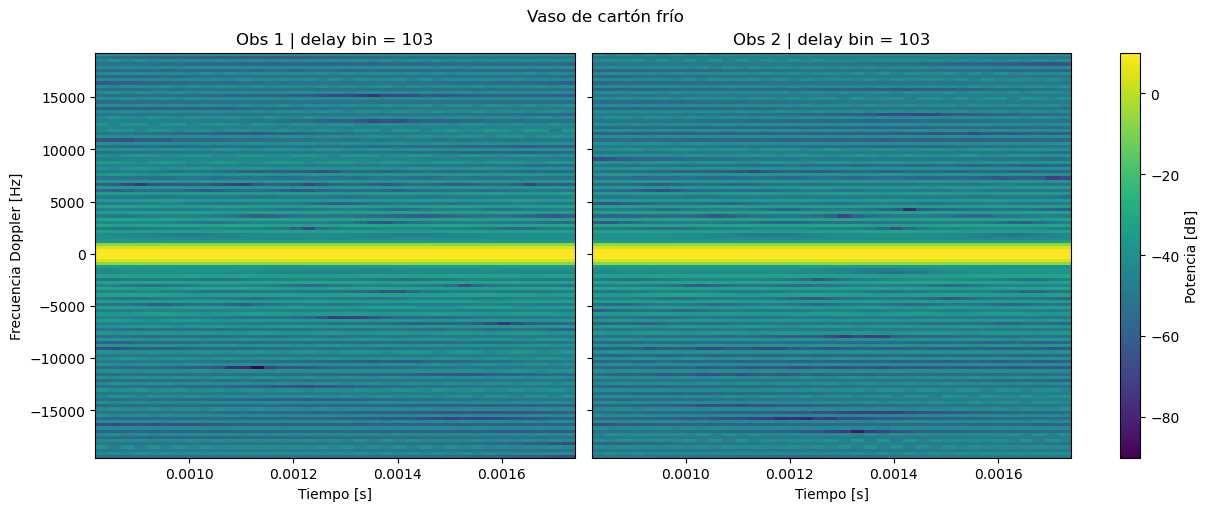

Delay bins seleccionados: 103 103


In [ ]:
# ============================================================
# Visualización
# ============================================================
selected_delay_bin_1 = (
    int(inter_1["selected_delay_bin"])
    if isinstance(inter_1, dict) and "selected_delay_bin" in inter_1 and inter_1["selected_delay_bin"] is not None
    else None
)
selected_delay_bin_2 = (
    int(inter_2["selected_delay_bin"])
    if isinstance(inter_2, dict) and "selected_delay_bin" in inter_2 and inter_2["selected_delay_bin"] is not None
    else None
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)
fig.suptitle("Vaso de cartón frío")

extent1 = (t_axis_1[0], t_axis_1[-1], f_axis_1[0], f_axis_1[-1])
extent2 = (t_axis_2[0], t_axis_2[-1], f_axis_2[0], f_axis_2[-1])

vmin = -90 # min(spec_db_1.min(), spec_db_2.min())
vmax = 10 # max(spec_db_1.max(), spec_db_2.max())

im0 = axs[0].imshow(
    spec_db_1,
    aspect="auto",
    origin="lower",
    extent=extent1,
    vmin=vmin,
    vmax=vmax,
)
axs[0].set_xlabel("Tiempo [s]")
axs[0].set_ylabel("Frecuencia Doppler [Hz]")
axs[0].set_title(f"Obs 1 | delay bin = {selected_delay_bin_1}")

im1 = axs[1].imshow(
    spec_db_2,
    aspect="auto",
    origin="lower",
    extent=extent2,
    vmin=vmin,
    vmax=vmax,
)
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_title(f"Obs 2 | delay bin = {selected_delay_bin_2}")

fig.colorbar(im0, ax=axs, label="Potencia [dB]")

plt.show()

print("Delay bins seleccionados:", selected_delay_bin_1, selected_delay_bin_2)

## Vaso de cristal caliente

In [ ]:
# ============================================================
# Adaptar IQ -> rejillas OFDM completas X[k,m], Y[k,m]
# ============================================================
TX_FILE_1 = "cristal/caliente/iq_tx_1.bin"
RX_FILE_1 = "cristal/caliente/iq_rx_1.bin"
TX_FILE_2 = "cristal/caliente/iq_tx_2.bin"
RX_FILE_2 = "cristal/caliente/iq_rx_2.bin"

obs_1 = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE_1,
    rx_file_path=RX_FILE_1,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

obs_2 = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE_2,
    rx_file_path=RX_FILE_2,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

In [ ]:
# ============================================================
# Pipeline OpenISAC-like completo:
# Y/X -> clutter suppression -> IFFT en subportadoras
# -> selección de bin de retardo -> STFT
# ============================================================
(spec_db_1, f_axis_1, t_axis_1), inter_1 = microdoppler_spectrogram_from_full_grid(
    y_grid=obs_1.y_grid,
    x_grid=obs_1.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

(spec_db_2, f_axis_2, t_axis_2), inter_2 = microdoppler_spectrogram_from_full_grid(
    y_grid=obs_2.y_grid,
    x_grid=obs_2.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

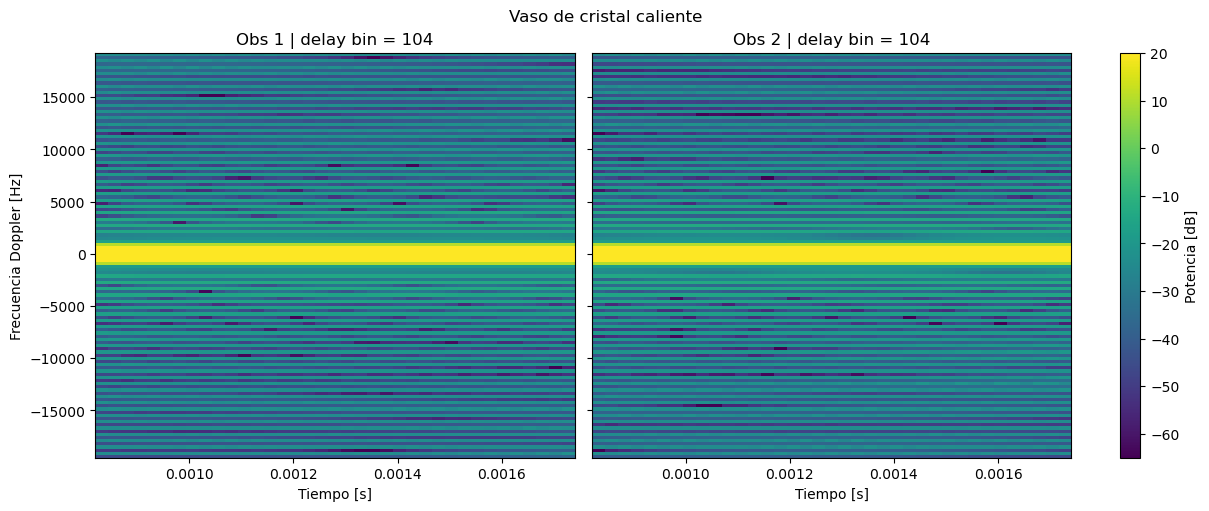

Delay bins seleccionados: 104 104


In [ ]:
# ============================================================
# Visualización
# ============================================================
selected_delay_bin_1 = (
    int(inter_1["selected_delay_bin"])
    if isinstance(inter_1, dict) and "selected_delay_bin" in inter_1 and inter_1["selected_delay_bin"] is not None
    else None
)
selected_delay_bin_2 = (
    int(inter_2["selected_delay_bin"])
    if isinstance(inter_2, dict) and "selected_delay_bin" in inter_2 and inter_2["selected_delay_bin"] is not None
    else None
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)
fig.suptitle("Vaso de cristal caliente")

extent1 = (t_axis_1[0], t_axis_1[-1], f_axis_1[0], f_axis_1[-1])
extent2 = (t_axis_2[0], t_axis_2[-1], f_axis_2[0], f_axis_2[-1])

vmin = -65 # min(spec_db_1.min(), spec_db_2.min())
vmax = 20 # max(spec_db_1.max(), spec_db_2.max())

im0 = axs[0].imshow(
    spec_db_1,
    aspect="auto",
    origin="lower",
    extent=extent1,
    vmin=vmin,
    vmax=vmax,
)
axs[0].set_xlabel("Tiempo [s]")
axs[0].set_ylabel("Frecuencia Doppler [Hz]")
axs[0].set_title(f"Obs 1 | delay bin = {selected_delay_bin_1}")

im1 = axs[1].imshow(
    spec_db_2,
    aspect="auto",
    origin="lower",
    extent=extent2,
    vmin=vmin,
    vmax=vmax,
)
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_title(f"Obs 2 | delay bin = {selected_delay_bin_2}")

fig.colorbar(im0, ax=axs, label="Potencia [dB]")

plt.show()

print("Delay bins seleccionados:", selected_delay_bin_1, selected_delay_bin_2)

## Vaso de cristal templado

In [ ]:
# ============================================================
# Adaptar IQ -> rejillas OFDM completas X[k,m], Y[k,m]
# ============================================================
TX_FILE_1 = "cristal/templado/iq_tx_1.bin"
RX_FILE_1 = "cristal/templado/iq_rx_1.bin"
TX_FILE_2 = "cristal/templado/iq_tx_2.bin"
RX_FILE_2 = "cristal/templado/iq_rx_2.bin"

obs_1 = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE_1,
    rx_file_path=RX_FILE_1,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

obs_2 = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE_2,
    rx_file_path=RX_FILE_2,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

In [ ]:
# ============================================================
# Pipeline OpenISAC-like completo:
# Y/X -> clutter suppression -> IFFT en subportadoras
# -> selección de bin de retardo -> STFT
# ============================================================
(spec_db_1, f_axis_1, t_axis_1), inter_1 = microdoppler_spectrogram_from_full_grid(
    y_grid=obs_1.y_grid,
    x_grid=obs_1.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

(spec_db_2, f_axis_2, t_axis_2), inter_2 = microdoppler_spectrogram_from_full_grid(
    y_grid=obs_2.y_grid,
    x_grid=obs_2.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

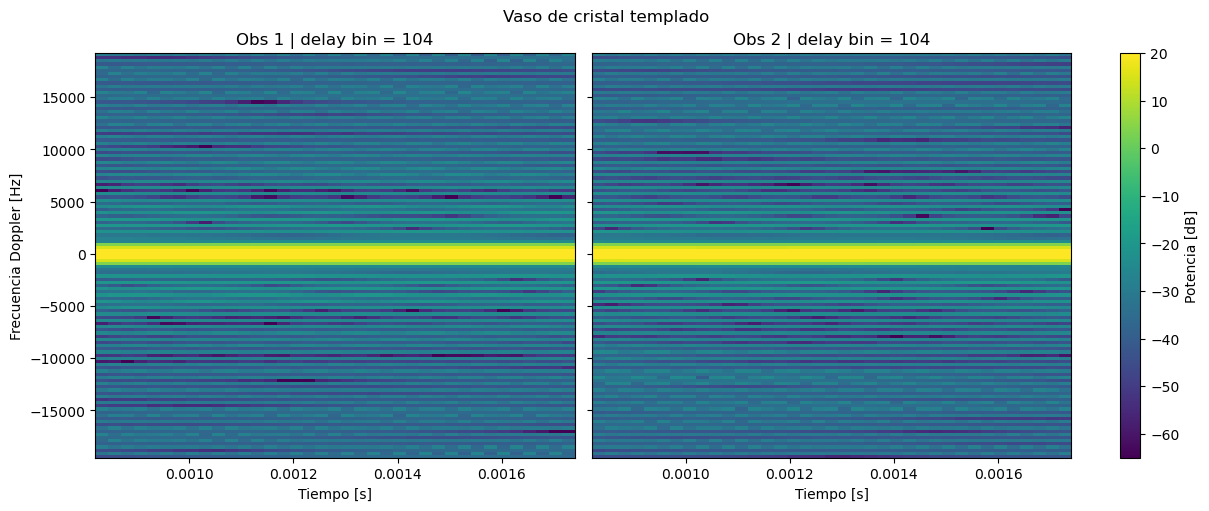

Delay bins seleccionados: 104 104


In [ ]:
# ============================================================
# Visualización
# ============================================================
selected_delay_bin_1 = (
    int(inter_1["selected_delay_bin"])
    if isinstance(inter_1, dict) and "selected_delay_bin" in inter_1 and inter_1["selected_delay_bin"] is not None
    else None
)
selected_delay_bin_2 = (
    int(inter_2["selected_delay_bin"])
    if isinstance(inter_2, dict) and "selected_delay_bin" in inter_2 and inter_2["selected_delay_bin"] is not None
    else None
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)
fig.suptitle("Vaso de cristal templado")

extent1 = (t_axis_1[0], t_axis_1[-1], f_axis_1[0], f_axis_1[-1])
extent2 = (t_axis_2[0], t_axis_2[-1], f_axis_2[0], f_axis_2[-1])

vmin = -65 # min(spec_db_1.min(), spec_db_2.min())
vmax = 20 # max(spec_db_1.max(), spec_db_2.max())

im0 = axs[0].imshow(
    spec_db_1,
    aspect="auto",
    origin="lower",
    extent=extent1,
    vmin=vmin,
    vmax=vmax,
)
axs[0].set_xlabel("Tiempo [s]")
axs[0].set_ylabel("Frecuencia Doppler [Hz]")
axs[0].set_title(f"Obs 1 | delay bin = {selected_delay_bin_1}")

im1 = axs[1].imshow(
    spec_db_2,
    aspect="auto",
    origin="lower",
    extent=extent2,
    vmin=vmin,
    vmax=vmax,
)
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_title(f"Obs 2 | delay bin = {selected_delay_bin_2}")

fig.colorbar(im0, ax=axs, label="Potencia [dB]")

plt.show()

print("Delay bins seleccionados:", selected_delay_bin_1, selected_delay_bin_2)

## Vaso de cristal frío

In [ ]:
# ============================================================
# Adaptar IQ -> rejillas OFDM completas X[k,m], Y[k,m]
# ============================================================
TX_FILE_1 = "cristal/frio/iq_tx_1.bin"
RX_FILE_1 = "cristal/frio/iq_rx_1.bin"
TX_FILE_2 = "cristal/frio/iq_tx_2.bin"
RX_FILE_2 = "cristal/frio/iq_rx_2.bin"

obs_1 = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE_1,
    rx_file_path=RX_FILE_1,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

obs_2 = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE_2,
    rx_file_path=RX_FILE_2,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

In [ ]:
# ============================================================
# Pipeline OpenISAC-like completo:
# Y/X -> clutter suppression -> IFFT en subportadoras
# -> selección de bin de retardo -> STFT
# ============================================================
(spec_db_1, f_axis_1, t_axis_1), inter_1 = microdoppler_spectrogram_from_full_grid(
    y_grid=obs_1.y_grid,
    x_grid=obs_1.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

(spec_db_2, f_axis_2, t_axis_2), inter_2 = microdoppler_spectrogram_from_full_grid(
    y_grid=obs_2.y_grid,
    x_grid=obs_2.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

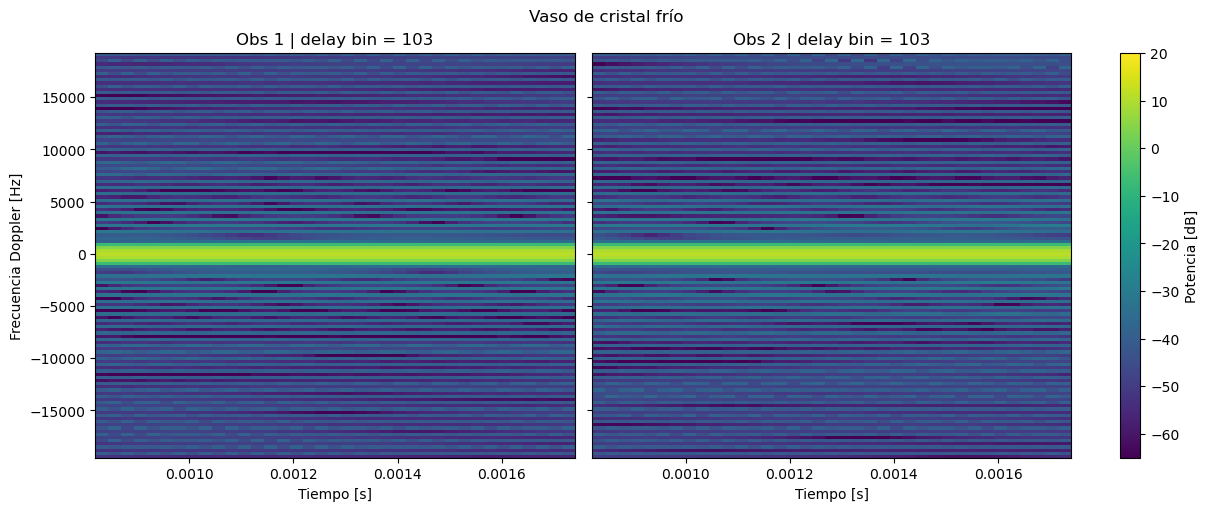

Delay bins seleccionados: 103 103


In [ ]:
# ============================================================
# Visualización
# ============================================================
selected_delay_bin_1 = (
    int(inter_1["selected_delay_bin"])
    if isinstance(inter_1, dict) and "selected_delay_bin" in inter_1 and inter_1["selected_delay_bin"] is not None
    else None
)
selected_delay_bin_2 = (
    int(inter_2["selected_delay_bin"])
    if isinstance(inter_2, dict) and "selected_delay_bin" in inter_2 and inter_2["selected_delay_bin"] is not None
    else None
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)
fig.suptitle("Vaso de cristal frío")

extent1 = (t_axis_1[0], t_axis_1[-1], f_axis_1[0], f_axis_1[-1])
extent2 = (t_axis_2[0], t_axis_2[-1], f_axis_2[0], f_axis_2[-1])

vmin = -65 # min(spec_db_1.min(), spec_db_2.min())
vmax = 20 # max(spec_db_1.max(), spec_db_2.max())

im0 = axs[0].imshow(
    spec_db_1,
    aspect="auto",
    origin="lower",
    extent=extent1,
    vmin=vmin,
    vmax=vmax,
)
axs[0].set_xlabel("Tiempo [s]")
axs[0].set_ylabel("Frecuencia Doppler [Hz]")
axs[0].set_title(f"Obs 1 | delay bin = {selected_delay_bin_1}")

im1 = axs[1].imshow(
    spec_db_2,
    aspect="auto",
    origin="lower",
    extent=extent2,
    vmin=vmin,
    vmax=vmax,
)
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_title(f"Obs 2 | delay bin = {selected_delay_bin_2}")

fig.colorbar(im0, ax=axs, label="Potencia [dB]")

plt.show()

print("Delay bins seleccionados:", selected_delay_bin_1, selected_delay_bin_2)

## Vaso de plástico caliente

In [ ]:
# ============================================================
# Adaptar IQ -> rejillas OFDM completas X[k,m], Y[k,m]
# ============================================================
TX_FILE_1 = "plastico/caliente/iq_tx_1.bin"
RX_FILE_1 = "plastico/caliente/iq_rx_1.bin"
TX_FILE_2 = "plastico/caliente/iq_tx_2.bin"
RX_FILE_2 = "plastico/caliente/iq_rx_2.bin"

obs_1 = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE_1,
    rx_file_path=RX_FILE_1,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

obs_2 = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE_2,
    rx_file_path=RX_FILE_2,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

In [ ]:
# ============================================================
# Pipeline OpenISAC-like completo:
# Y/X -> clutter suppression -> IFFT en subportadoras
# -> selección de bin de retardo -> STFT
# ============================================================
(spec_db_1, f_axis_1, t_axis_1), inter_1 = microdoppler_spectrogram_from_full_grid(
    y_grid=obs_1.y_grid,
    x_grid=obs_1.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

(spec_db_2, f_axis_2, t_axis_2), inter_2 = microdoppler_spectrogram_from_full_grid(
    y_grid=obs_2.y_grid,
    x_grid=obs_2.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

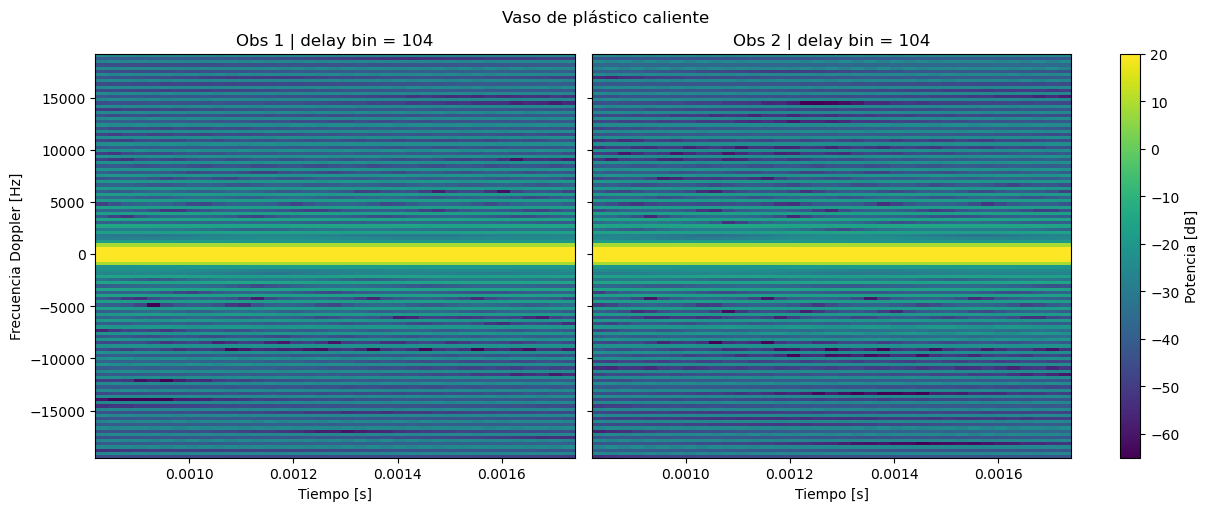

Delay bins seleccionados: 104 104


In [ ]:
# ============================================================
# Visualización
# ============================================================
selected_delay_bin_1 = (
    int(inter_1["selected_delay_bin"])
    if isinstance(inter_1, dict) and "selected_delay_bin" in inter_1 and inter_1["selected_delay_bin"] is not None
    else None
)
selected_delay_bin_2 = (
    int(inter_2["selected_delay_bin"])
    if isinstance(inter_2, dict) and "selected_delay_bin" in inter_2 and inter_2["selected_delay_bin"] is not None
    else None
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)
fig.suptitle("Vaso de plástico caliente")

extent1 = (t_axis_1[0], t_axis_1[-1], f_axis_1[0], f_axis_1[-1])
extent2 = (t_axis_2[0], t_axis_2[-1], f_axis_2[0], f_axis_2[-1])

vmin = -65 # min(spec_db_1.min(), spec_db_2.min())
vmax = 20 # max(spec_db_1.max(), spec_db_2.max())

im0 = axs[0].imshow(
    spec_db_1,
    aspect="auto",
    origin="lower",
    extent=extent1,
    vmin=vmin,
    vmax=vmax,
)
axs[0].set_xlabel("Tiempo [s]")
axs[0].set_ylabel("Frecuencia Doppler [Hz]")
axs[0].set_title(f"Obs 1 | delay bin = {selected_delay_bin_1}")

im1 = axs[1].imshow(
    spec_db_2,
    aspect="auto",
    origin="lower",
    extent=extent2,
    vmin=vmin,
    vmax=vmax,
)
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_title(f"Obs 2 | delay bin = {selected_delay_bin_2}")

fig.colorbar(im0, ax=axs, label="Potencia [dB]")

plt.show()

print("Delay bins seleccionados:", selected_delay_bin_1, selected_delay_bin_2)

## Vaso de plástico templado

In [ ]:
# ============================================================
# Adaptar IQ -> rejillas OFDM completas X[k,m], Y[k,m]
# ============================================================
TX_FILE_1 = "plastico/templado/iq_tx_1.bin"
RX_FILE_1 = "plastico/templado/iq_rx_1.bin"
TX_FILE_2 = "plastico/templado/iq_tx_2.bin"
RX_FILE_2 = "plastico/templado/iq_rx_2.bin"

obs_1 = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE_1,
    rx_file_path=RX_FILE_1,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

obs_2 = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE_2,
    rx_file_path=RX_FILE_2,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

In [ ]:
# ============================================================
# Pipeline OpenISAC-like completo:
# Y/X -> clutter suppression -> IFFT en subportadoras
# -> selección de bin de retardo -> STFT
# ============================================================
(spec_db_1, f_axis_1, t_axis_1), inter_1 = microdoppler_spectrogram_from_full_grid(
    y_grid=obs_1.y_grid,
    x_grid=obs_1.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

(spec_db_2, f_axis_2, t_axis_2), inter_2 = microdoppler_spectrogram_from_full_grid(
    y_grid=obs_2.y_grid,
    x_grid=obs_2.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

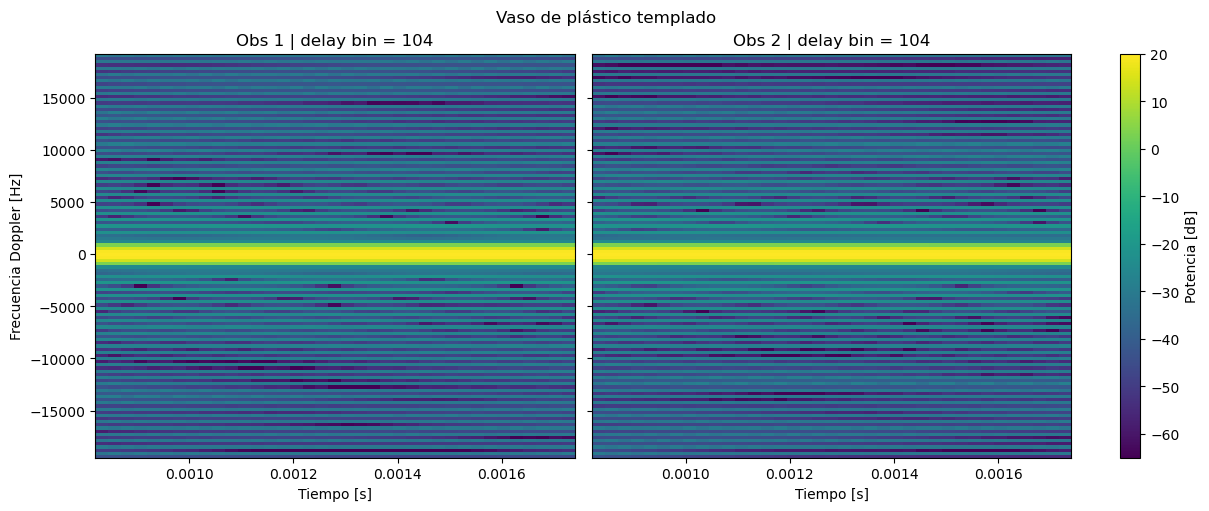

Delay bins seleccionados: 104 104


In [ ]:
# ============================================================
# Visualización
# ============================================================
selected_delay_bin_1 = (
    int(inter_1["selected_delay_bin"])
    if isinstance(inter_1, dict) and "selected_delay_bin" in inter_1 and inter_1["selected_delay_bin"] is not None
    else None
)
selected_delay_bin_2 = (
    int(inter_2["selected_delay_bin"])
    if isinstance(inter_2, dict) and "selected_delay_bin" in inter_2 and inter_2["selected_delay_bin"] is not None
    else None
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)
fig.suptitle("Vaso de plástico templado")

extent1 = (t_axis_1[0], t_axis_1[-1], f_axis_1[0], f_axis_1[-1])
extent2 = (t_axis_2[0], t_axis_2[-1], f_axis_2[0], f_axis_2[-1])

vmin = -65 # min(spec_db_1.min(), spec_db_2.min())
vmax = 20 # max(spec_db_1.max(), spec_db_2.max())

im0 = axs[0].imshow(
    spec_db_1,
    aspect="auto",
    origin="lower",
    extent=extent1,
    vmin=vmin,
    vmax=vmax,
)
axs[0].set_xlabel("Tiempo [s]")
axs[0].set_ylabel("Frecuencia Doppler [Hz]")
axs[0].set_title(f"Obs 1 | delay bin = {selected_delay_bin_1}")

im1 = axs[1].imshow(
    spec_db_2,
    aspect="auto",
    origin="lower",
    extent=extent2,
    vmin=vmin,
    vmax=vmax,
)
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_title(f"Obs 2 | delay bin = {selected_delay_bin_2}")

fig.colorbar(im0, ax=axs, label="Potencia [dB]")

plt.show()

print("Delay bins seleccionados:", selected_delay_bin_1, selected_delay_bin_2)

## Vaso de plástico frío

In [ ]:
# ============================================================
# Adaptar IQ -> rejillas OFDM completas X[k,m], Y[k,m]
# ============================================================
TX_FILE_1 = "plastico/frio/iq_tx_1.bin"
RX_FILE_1 = "plastico/frio/iq_rx_1.bin"
TX_FILE_2 = "plastico/frio/iq_tx_2.bin"
RX_FILE_2 = "plastico/frio/iq_rx_2.bin"

obs_1 = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE_1,
    rx_file_path=RX_FILE_1,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

obs_2 = adapt_to_ofdm_grid_observation(
    "usrp_iq",
    tx_file_path=TX_FILE_2,
    rx_file_path=RX_FILE_2,
    fft_size=FFT_SIZE,
    cp_len=CP_LEN,
    n_symbols=NUM_SYMBOLS,
    usrp_file_dtype=USRP_FILE_DTYPE,
    keep_time_domain=False,
)

In [ ]:
# ============================================================
# Pipeline OpenISAC-like completo:
# Y/X -> clutter suppression -> IFFT en subportadoras
# -> selección de bin de retardo -> STFT
# ============================================================
(spec_db_1, f_axis_1, t_axis_1), inter_1 = microdoppler_spectrogram_from_full_grid(
    y_grid=obs_1.y_grid,
    x_grid=obs_1.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

(spec_db_2, f_axis_2, t_axis_2), inter_2 = microdoppler_spectrogram_from_full_grid(
    y_grid=obs_2.y_grid,
    x_grid=obs_2.x_grid,
    fs_slow=FS_SLOW,
    method="openisac",
    downsample_factor=1,
    clutter_mode="none",
    hp_alpha=0.98,
    delay_bin_strategy="strongest",
    nperseg=nperseg,
    noverlap=noverlap,
    window="hamming",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

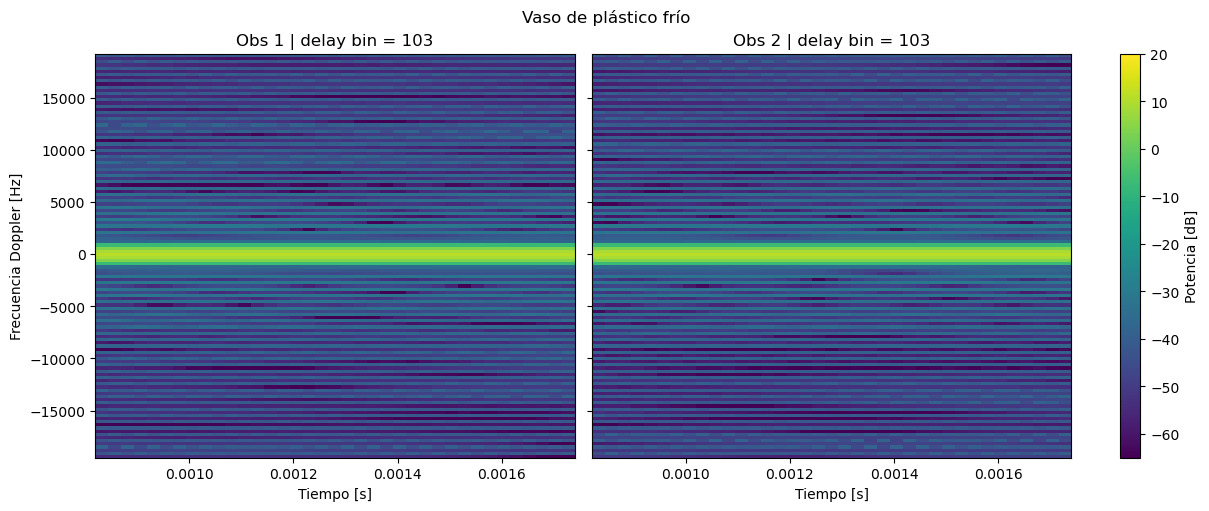

Delay bins seleccionados: 103 103


In [ ]:
# ============================================================
# Visualización
# ============================================================
selected_delay_bin_1 = (
    int(inter_1["selected_delay_bin"])
    if isinstance(inter_1, dict) and "selected_delay_bin" in inter_1 and inter_1["selected_delay_bin"] is not None
    else None
)
selected_delay_bin_2 = (
    int(inter_2["selected_delay_bin"])
    if isinstance(inter_2, dict) and "selected_delay_bin" in inter_2 and inter_2["selected_delay_bin"] is not None
    else None
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)
fig.suptitle("Vaso de plástico frío")

extent1 = (t_axis_1[0], t_axis_1[-1], f_axis_1[0], f_axis_1[-1])
extent2 = (t_axis_2[0], t_axis_2[-1], f_axis_2[0], f_axis_2[-1])

vmin = -65 # min(spec_db_1.min(), spec_db_2.min())
vmax = 20 # max(spec_db_1.max(), spec_db_2.max())

im0 = axs[0].imshow(
    spec_db_1,
    aspect="auto",
    origin="lower",
    extent=extent1,
    vmin=vmin,
    vmax=vmax,
)
axs[0].set_xlabel("Tiempo [s]")
axs[0].set_ylabel("Frecuencia Doppler [Hz]")
axs[0].set_title(f"Obs 1 | delay bin = {selected_delay_bin_1}")

im1 = axs[1].imshow(
    spec_db_2,
    aspect="auto",
    origin="lower",
    extent=extent2,
    vmin=vmin,
    vmax=vmax,
)
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_title(f"Obs 2 | delay bin = {selected_delay_bin_2}")

fig.colorbar(im0, ax=axs, label="Potencia [dB]")

plt.show()

print("Delay bins seleccionados:", selected_delay_bin_1, selected_delay_bin_2)

## Diferencia de fase

h_grid: (100, 1024)
s_grid: (99, 1024)
slow_seq: (99,)
spec: (128, 36)


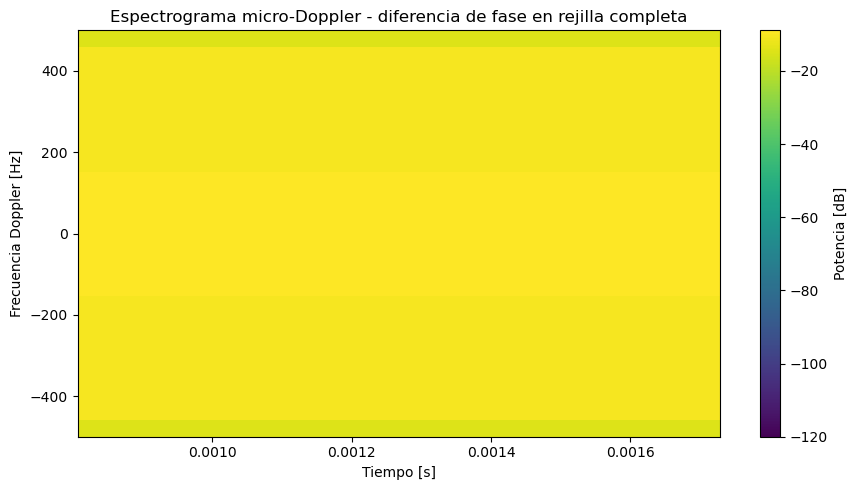

In [ ]:
# ============================================================
# Pipeline micro-Doppler con DIFERENCIA DE FASE en rejilla completa
# ============================================================

(spec, f_axis, t_axis), inter = microdoppler_spectrogram_from_full_grid(
    y_grid=obs.y_grid,
    x_grid=obs.x_grid,
    fs_slow=FS_SLOW,

    # CAMBIO IMPORTANTE:
    method="phase_difference",

    # Diferencia de fase:
    # current_next: S[m,k] = H[m,k] * conj(H[m+1,k])
    # next_current: cambia el signo del eje Doppler
    use_conjugate_order="current_next",

    # Agregación sobre todas las subportadoras
    aggregation_mode="noncoherent_mean_power",
    min_valid_subcarriers=1,

    # Parámetros STFT
    nperseg=nperseg,
    noverlap=noverlap,
    window="hann",
    nfft=nfft,
    detrend=False,
    center_frequency_axis=True,
    to_db=True,
    return_intermediates=True,
)

print("h_grid:", inter["h_grid"].shape)
print("s_grid:", inter["s_grid"].shape)
print("slow_seq:", inter["slow_seq"].shape)
print("spec:", spec.shape)

# ============================================================
# Representación
# ============================================================

plt.figure(figsize=(9, 5))
plt.pcolormesh(t_axis, f_axis, spec, shading="auto")
plt.xlabel("Tiempo [s]")
plt.ylabel("Frecuencia Doppler [Hz]")
plt.title("Espectrograma micro-Doppler - diferencia de fase en rejilla completa")
plt.colorbar(label="Potencia [dB]")
plt.ylim(-500, 500)   # ajusta según lo que quieras ver
plt.tight_layout()
plt.show()